# Step 01 — ERA5 Data Download
**Project:** ENSO-BSISO Self-Supervised Learning  
**Author:** Jiayi (jh9141@nyu.edu)

This notebook downloads ERA5 atmospheric fields from the Copernicus CDS:
- `u850` — zonal wind at 850 hPa  
- `v850` — meridional wind at 850 hPa  
- `OLR` — top net thermal radiation (proxy for outgoing longwave radiation)

**Domain:** 60°E–160°E, 0°N–60°N, 2° resolution  
**Period:** July only, 1979–2023 (45 years, ~1,395 daily samples)

---

## ⚠️ Prerequisites — Do This BEFORE Running Any Cells

### 1. Create a CDS Account
1. Go to **https://cds.climate.copernicus.eu/**
2. Click **Register** → fill in your details → verify your email
3. Log in → click your name (top right) → **Your profile**
4. Scroll down to find your **Personal Access Token** — copy it

### 2. Accept the ERA5 License
You must accept the data license before downloading:
1. Go to: **https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels**
2. Scroll down → click **Terms of use** → Accept
3. Go to: **https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels**
4. Scroll down → click **Terms of use** → Accept

### 3. Runtime Settings
Set Colab to GPU: **Runtime → Change runtime type → T4 GPU**

---

## Cell 1 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


## Cell 2 — Create Project Folder Structure on Google Drive

In [4]:
import os

# Base project directory on Google Drive
PROJECT_DIR = '/content/drive/MyDrive/BSISO_SSL_Project'

# Create all subdirectories
dirs = [
    f'{PROJECT_DIR}/data/raw',
    f'{PROJECT_DIR}/data/processed',
    f'{PROJECT_DIR}/notebooks',
    f'{PROJECT_DIR}/src',
    f'{PROJECT_DIR}/checkpoints',
    f'{PROJECT_DIR}/results',
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f'Created: {d}')

print('\nFolder structure ready!')

Created: /content/drive/MyDrive/BSISO_SSL_Project/data/raw
Created: /content/drive/MyDrive/BSISO_SSL_Project/data/processed
Created: /content/drive/MyDrive/BSISO_SSL_Project/notebooks
Created: /content/drive/MyDrive/BSISO_SSL_Project/src
Created: /content/drive/MyDrive/BSISO_SSL_Project/checkpoints
Created: /content/drive/MyDrive/BSISO_SSL_Project/results

Folder structure ready!


## Cell 3 — Install CDS API Client

In [5]:
!pip install cdsapi --quiet
import cdsapi

## Cell 4 — Set Up CDS API Credentials

**Fill in your Personal Access Token below.**  
Find it at: https://cds.climate.copernicus.eu/ → Your profile → Personal Access Token

In [6]:
# ============================================================
# FILL IN YOUR API KEY HERE
# ============================================================
CDS_API_KEY = 'bcc4c8e7-b5e7-44de-8f1d-d7414aab9a51'
# ============================================================

# Write the .cdsapirc config file
cdsapirc_content = f"""url: https://cds.climate.copernicus.eu/api
key: bcc4c8e7-b5e7-44de-8f1d-d7414aab9a51
"""

with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(cdsapirc_content)

print('CDS API credentials saved to ~/.cdsapirc')

# Test connection
try:
    client = cdsapi.Client(quiet=True)
    print('CDS API connection: OK')
except Exception as e:
    print(f'CDS API connection FAILED: {e}')
    print('Check your API key and make sure you accepted the data licenses.')

CDS API credentials saved to ~/.cdsapirc
CDS API connection: OK


## Cell 5 — Download u850 + v850 (ERA5 Pressure Levels)

Downloads zonal wind (u) and meridional wind (v) at 850 hPa.  
**Estimated time:** 10–30 min (depends on CDS queue)  
**File size:** ~40–60 MB

In [10]:
import cdsapi
import os

# --- FIX: Ensure PROJECT_DIR is defined ---
if 'PROJECT_DIR' not in locals():
    PROJECT_DIR = '/content/drive/MyDrive/BSISO_SSL_Project'
# ------------------------------------------

# --- FIX: Ensure API Key is configured ---
if not os.path.exists(os.path.expanduser('~/.cdsapirc')):
    with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
        f.write("url: https://cds.climate.copernicus.eu/api\n")
        f.write("key: bcc4c8e7-b5e7-44de-8f1d-d7414aab9a51\n")
    print("Re-created ~/.cdsapirc configuration file.")
# -----------------------------------------

client = cdsapi.Client()

# Define smaller year chunks (e.g., ~10 years) to avoid cost limits
year_chunks = [
    (1979, 1989),
    (1990, 1999),
    (2000, 2009),
    (2010, 2019),
    (2020, 2023)
]

for start_year, end_year in year_chunks:
    output_wind = f'{PROJECT_DIR}/data/raw/u850_v850_July_{start_year}_{end_year}.nc'

    # Skip if already downloaded
    if os.path.exists(output_wind):
        size_mb = os.path.getsize(output_wind) / 1e6
        print(f'File already exists: {os.path.basename(output_wind)} ({size_mb:.1f} MB), skipping download.')
    else:
        print(f'\nSubmitting request for years {start_year}-{end_year} to CDS... (may queue for a few minutes)')
        print('This is normal — CDS processes requests in order.')
        print('Do NOT close this tab!')
        print()

        try:
            client.retrieve(
                'reanalysis-era5-pressure-levels',
                {
                    'product_type': 'reanalysis',
                    'variable': [
                        'u_component_of_wind',
                        'v_component_of_wind',
                    ],
                    'pressure_level': '850',
                    'year': [str(y) for y in range(start_year, end_year + 1)],
                    'month': '07',
                    'day': [f'{d:02d}' for d in range(1, 32)],
                    'time': '12:00',
                    'area': [60, 60, 0, 160],
                    'grid': [2.0, 2.0],
                    'format': 'netcdf',
                    'data_format': 'netcdf',
                },
                output_wind
            )

            size_mb = os.path.getsize(output_wind) / 1e6
            print(f'\nDownload complete! File saved: {os.path.basename(output_wind)} ({size_mb:.1f} MB)')
        except Exception as e:
            print(f'\nERROR during download for years {start_year}-{end_year}: {e}')
            print('Please review the error message and consider reducing the year range further or checking your CDS account status.')

print('\nAll wind data chunks processed.')

2026-03-03 03:23:02,756 INFO [2026-02-25T00:00:00Z] Please note that the announced software upgrade for extracting geographical-area data from selected ERA5 and Seasonal Forecast datasets was successfully implemented on 25 February. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/software-upgrade-for-data-extraction-of-a-geographical-area-from-selected-era5-and-seasonal-forecast-datasets/14583).
INFO:ecmwf.datastores.legacy_client:[2026-02-25T00:00:00Z] Please note that the announced software upgrade for extracting geographical-area data from selected ERA5 and Seasonal Forecast datasets was successfully implemented on 25 February. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/software-upgrade-for-data-extraction-of-a-geographical-area-from-selected-era5-and-seasonal-forecast-datasets/14583).



Submitting request for years 1979-1989 to CDS... (may queue for a few minutes)
This is normal — CDS processes requests in order.
Do NOT close this tab!



2026-03-03 03:23:03,207 INFO Request ID is cf207871-1bda-4b7b-8b53-54998e518070
INFO:ecmwf.datastores.legacy_client:Request ID is cf207871-1bda-4b7b-8b53-54998e518070
2026-03-03 03:23:04,706 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-03 03:23:10,022 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-03 03:24:21,235 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


566ea2c50a28d1e3b5717410afb985bf.nc:   0%|          | 0.00/2.79M [00:00<?, ?B/s]


Download complete! File saved: u850_v850_July_1979_1989.nc (2.9 MB)

Submitting request for years 1990-1999 to CDS... (may queue for a few minutes)
This is normal — CDS processes requests in order.
Do NOT close this tab!



...

a9d1fd030c726cb7a45ea5bacca2fbe4.nc:   0%|          | 0.00/2.56M [00:00<?, ?B/s]


Download complete! File saved: u850_v850_July_2010_2019.nc (2.7 MB)

Submitting request for years 2020-2023 to CDS... (may queue for a few minutes)
This is normal — CDS processes requests in order.
Do NOT close this tab!



2026-03-03 03:28:25,070 INFO Request ID is 54853487-bb74-431c-8597-1e8505012784
INFO:ecmwf.datastores.legacy_client:Request ID is 54853487-bb74-431c-8597-1e8505012784
2026-03-03 03:28:25,283 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-03 03:28:40,238 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-03 03:28:59,570 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


73a9d48353bdf4a48eb83fa3a0a6e25e.nc:   0%|          | 0.00/1.04M [00:00<?, ?B/s]


Download complete! File saved: u850_v850_July_2020_2023.nc (1.1 MB)

All wind data chunks processed.


In [8]:
!pip install cdsapi --quiet
import cdsapi

## Cell 6 — Download OLR Proxy (ERA5 Single Levels)

Downloads top net thermal radiation (proxy for outgoing longwave radiation).  
**Estimated time:** 10–20 min  
**File size:** ~20–30 MB

In [11]:
output_olr = f'{PROJECT_DIR}/data/raw/OLR_July_1979_2023.nc'

if os.path.exists(output_olr):
    size_mb = os.path.getsize(output_olr) / 1e6
    print(f'File already exists ({size_mb:.1f} MB), skipping download.')
else:
    print('Submitting OLR request to CDS...')
    print('Do NOT close this tab!')
    print()

    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'variable': 'top_net_thermal_radiation',
            'year': [str(y) for y in range(1979, 2024)],
            'month': '07',
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': '12:00',
            'area': [60, 60, 0, 160],
            'grid': [2.0, 2.0],
            'format': 'netcdf',
            'data_format': 'netcdf',
        },
        output_olr
    )

    size_mb = os.path.getsize(output_olr) / 1e6
    print(f'\nDownload complete! File saved: {output_olr} ({size_mb:.1f} MB)')

Submitting OLR request to CDS...
Do NOT close this tab!



2026-03-03 03:30:01,807 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

3000afee4f0e271356e61fcd01d43398.nc:   0%|          | 0.00/4.59M [00:00<?, ?B/s]


Download complete! File saved: /content/drive/MyDrive/BSISO_SSL_Project/data/raw/OLR_July_1979_2023.nc (4.8 MB)


## Cell 7 — Verify Downloads (Shape + Sanity Check)

In [16]:
import xarray as xr
import numpy as np

print('=' * 55)
print('VERIFICATION REPORT')
print('=' * 55)

# --- Wind file ---
print('\n[1] u850 / v850 file')
ds_wind = xr.open_dataset(output_wind)
print(ds_wind)

u850 = ds_wind['u'].values if 'u' in ds_wind else ds_wind['u10'].values
# Try common variable name variants
for var in ['u', 'u850', 'U']:
    if var in ds_wind:
        u850 = ds_wind[var].values
        print(f'  u variable name: {var}')
        break

print(f'  Time steps: {ds_wind.dims["valid_time"]}')
print(f'  NaN count (u): {np.isnan(u850).sum()}')
print(f'  u value range: [{np.nanmin(u850):.2f}, {np.nanmax(u850):.2f}] m/s')
print(f'  Expected u range: roughly -25 to +25 m/s')

# --- OLR file ---
print('\n[2] OLR file')
ds_olr = xr.open_dataset(output_olr)
print(ds_olr)

for var in ['ttr', 'TTR', 'mtnlwrf']:
    if var in ds_olr:
        olr = ds_olr[var].values
        print(f'  OLR variable name: {var}')
        break

print(f'  Time steps: {ds_wind.dims["valid_time"]}')
print(f'  NaN count: {np.isnan(olr).sum()}')
print(f'  OLR value range: [{np.nanmin(olr):.2f}, {np.nanmax(olr):.2f}]')
print(f'  Expected range: large negative values (J/m^2), divide by 86400 for W/m^2')

# --- Summary ---
print('\n' + '=' * 55)
print('FILES ON GOOGLE DRIVE:')
for f in [output_wind, output_olr]:
    if os.path.exists(f):
        mb = os.path.getsize(f) / 1e6
        print(f'  ✓ {os.path.basename(f)}  ({mb:.1f} MB)')
    else:
        print(f'  ✗ {os.path.basename(f)}  MISSING!')
print('=' * 55)

VERIFICATION REPORT

[1] u850 / v850 file
<xarray.Dataset> Size: 2MB
Dimensions:         (valid_time: 124, pressure_level: 1, latitude: 31,
                     longitude: 51)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 992B 2020-07-01T12:00:00 ... ...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 248B 60.0 58.0 56.0 54.0 ... 4.0 2.0 0.0
  * longitude       (longitude) float64 408B 60.0 62.0 64.0 ... 158.0 160.0
    number          int64 8B ...
    expver          (valid_time) <U4 2kB ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 784kB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 784kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-R

/tmp/ipykernel_585/1564474849.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  Time steps: {ds_wind.dims["valid_time"]}')
/tmp/ipykernel_585/1564474849.py:37: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  Time steps: {ds_wind.dims["valid_time"]}')


## Cell 8 — Quick Plot (Visual Sanity Check)

Plot one day of u850 and OLR to confirm the data looks correct.

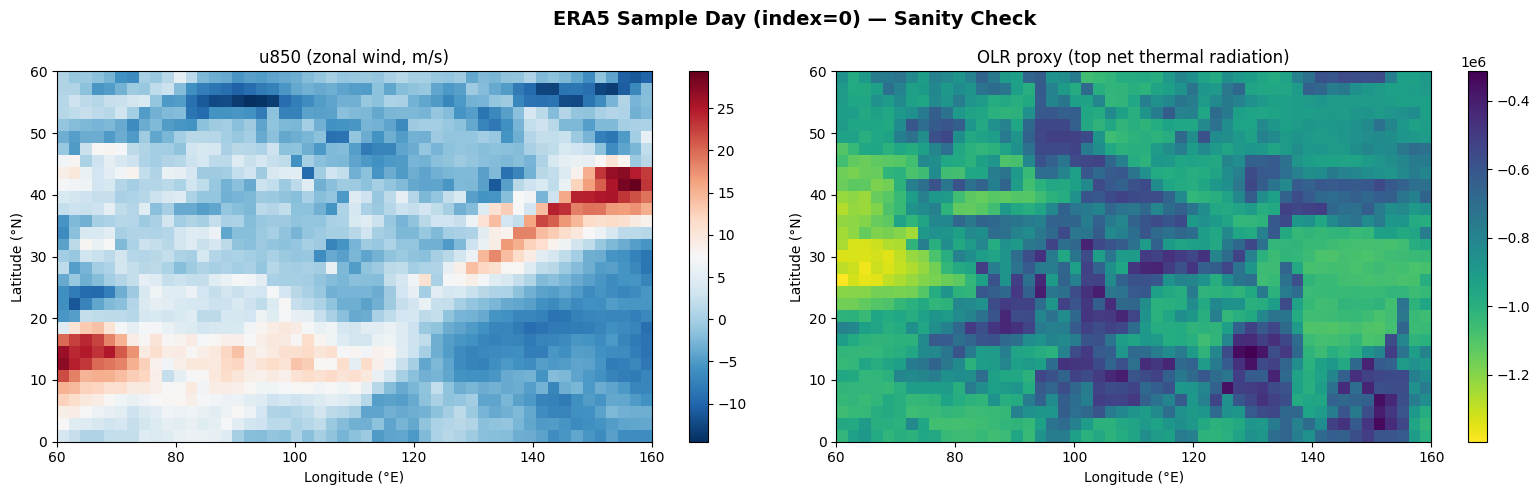

Plot saved to Google Drive!


In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Pick a sample day (index 0 = 1979-07-01)
sample_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ERA5 Sample Day (index={sample_idx}) — Sanity Check',
             fontsize=14, fontweight='bold')

# --- FIX: Detect correct time dimension name ---
time_dim_wind = 'valid_time' if 'valid_time' in ds_wind.dims else 'time'
time_dim_olr = 'valid_time' if 'valid_time' in ds_olr.dims else 'time'
# -----------------------------------------------

# u850
# Use dynamic dimension unpacking (**{key: value})
u_sample = ds_wind['u'].isel(**{time_dim_wind: sample_idx}).squeeze().values
im1 = axes[0].imshow(u_sample, cmap='RdBu_r', origin='upper',
                     extent=[60, 160, 0, 60], aspect='auto')
axes[0].set_title('u850 (zonal wind, m/s)', fontsize=12)
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
plt.colorbar(im1, ax=axes[0])

# OLR
olr_var_name = list(ds_olr.data_vars)[0]
olr_sample = ds_olr[olr_var_name].isel(**{time_dim_olr: sample_idx}).squeeze().values
im2 = axes[1].imshow(olr_sample, cmap='viridis_r', origin='upper',
                     extent=[60, 160, 0, 60], aspect='auto')
axes[1].set_title('OLR proxy (top net thermal radiation)', fontsize=12)
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/sanity_check_day0.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Google Drive!')

---
## Done!

If all cells ran successfully you should have on your Google Drive:

```
BSISO_SSL_Project/
└── data/
    └── raw/
        ├── u850_v850_July_1979_2023.nc
        └── OLR_July_1979_2023.nc
```

**Next step:** Run notebook `02_download_labels.ipynb` to get the BSISO phase index and NOAA ENSO index.

---
*DDCS Project | jh9141@nyu.edu*